In [12]:
# ============================================================
# F1 2025 - Tyre Degradation Analysis
# Author: Alexandre Larde
# Data source: FastF1 (official F1 timing data)
# ============================================================

# This notebook analyses lap time evolution and tyre degradation
# across stints for the top drivers of the 2025 British Grand Prix.
# Pit stops are highlighted with dashed vertical lines.

# Key observations:
# - Lap time increase within a stint = tyre degradation
# - Drop after pit stop = fresh tyre performance gain
# - Final laps acceleration = Safety Car / track evolution

In [13]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
session2 = fastf1.get_session(2025, 'Silverstone', 'R')
session2.load()
print("Chargé !")

core           INFO 	Loading data for British Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '27', '44', '1', '10', '18', '23', '14', '63', '87', '55', '31', '16', '22', '12', '6', '5', '30', '43']


Chargé !


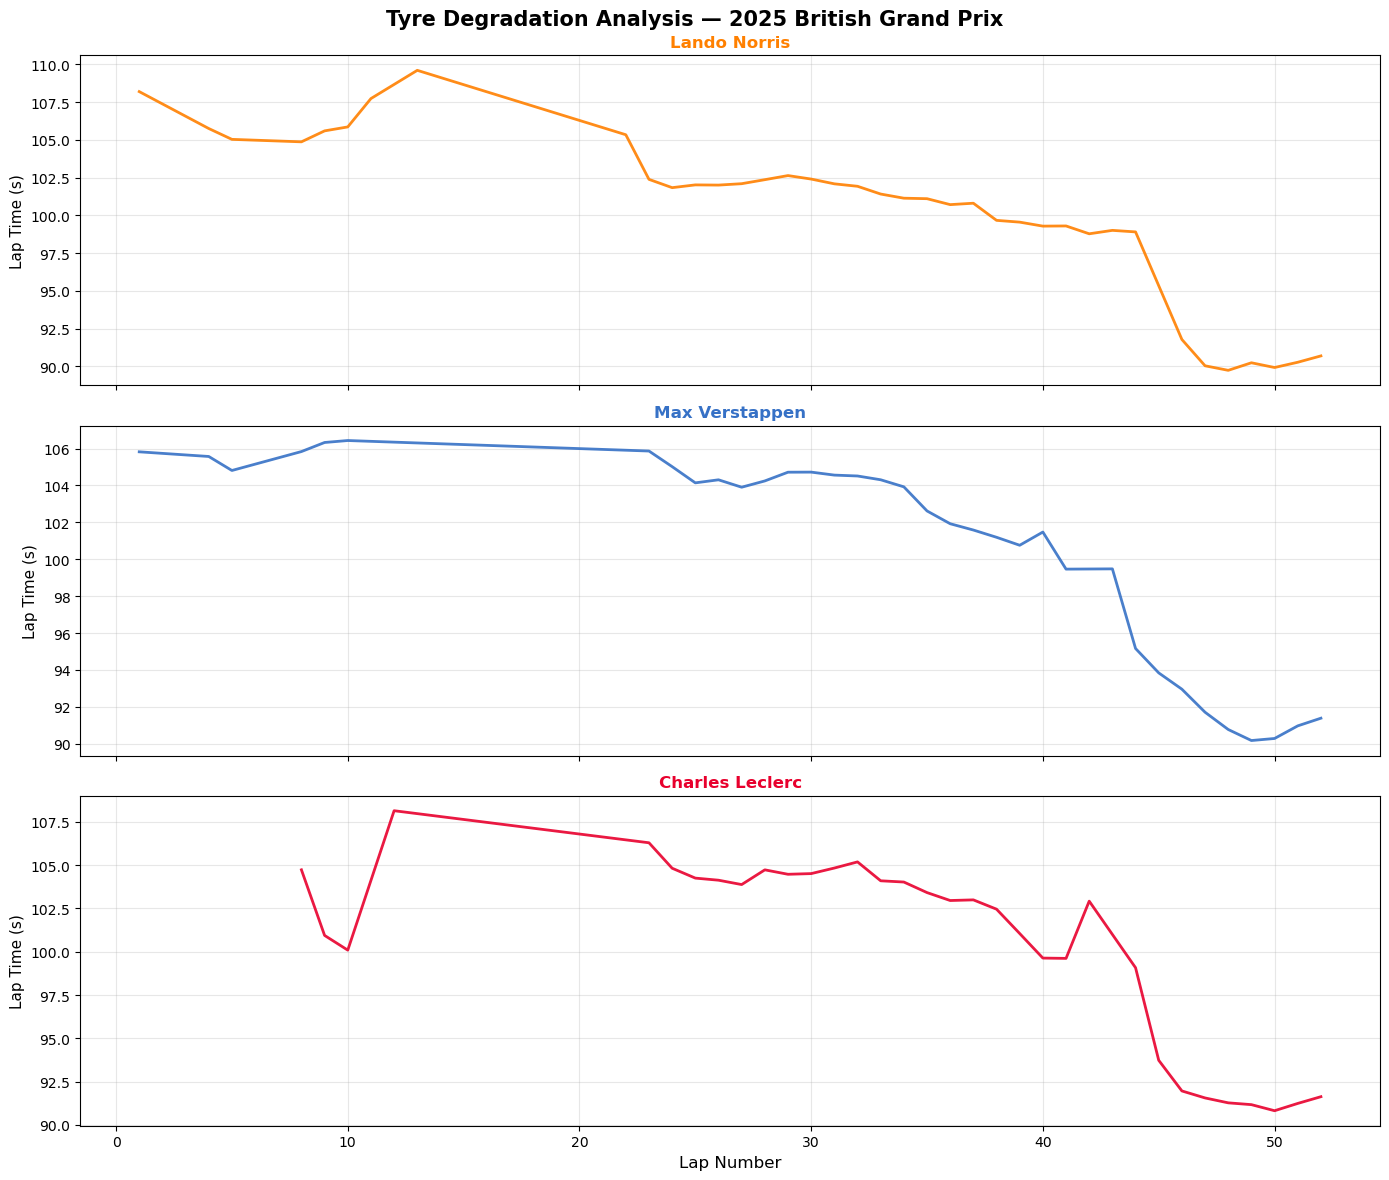

Saved !


In [15]:
laps2 = session2.laps

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

drivers = {'NOR': ('#FF8000', 'Lando Norris'), 
           'VER': ('#3671C6', 'Max Verstappen'), 
           'LEC': ('#E8002D', 'Charles Leclerc')}

for ax, (driver, (color, name)) in zip(axes, drivers.items()):
    data = laps2[laps2['Driver'] == driver].copy()
    clean = data[data['LapTime'].dt.total_seconds() < 110].dropna(subset=['LapTime'])
    
    # Tracer en une seule ligne continue, les trous apparaissent naturellement
    ax.plot(clean['LapNumber'],
            clean['LapTime'].dt.total_seconds(),
            color=color, linewidth=2, alpha=0.9)
    
    # Marquer les pit stops
    pit_laps = clean[clean['PitOutTime'].notna()]['LapNumber']
    for pit in pit_laps:
        ax.axvline(x=pit, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.annotate('PIT', xy=(pit, 109), fontsize=8, color='gray', ha='center')

    ax.set_ylabel('Lap Time (s)', fontsize=11)
    ax.set_title(name, fontsize=12, color=color, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Lap Number', fontsize=12)
fig.suptitle('Tyre Degradation Analysis — 2025 British Grand Prix', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('british_gp_2025_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved !")

In [17]:
import os
print(os.getcwd())

C:\Users\alexl
